<a href="https://colab.research.google.com/github/mannatkalani12-boop/Data-Analysing-/blob/main/Zomato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("zomato.csv", encoding="latin-1")
df_country=pd.read_excel("Country-Code.xlsx")

df_country

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia
5,148,New Zealand
6,162,Phillipines
7,166,Qatar
8,184,Singapore
9,189,South Africa


In [5]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [6]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

(9551, 21)

In [7]:
df.dropna(subset="Cuisines",inplace=True)

In [8]:
df.isnull().sum()


,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


<function matplotlib.pyplot.show(close=None, block=None)>

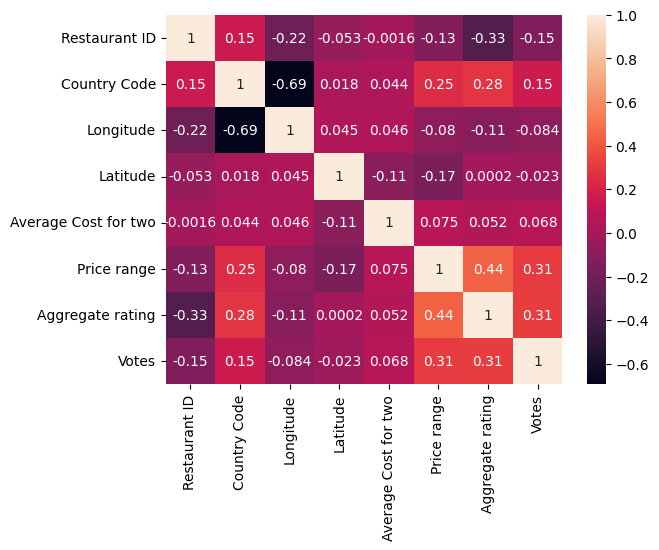

In [9]:
numeric_df=df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(),annot=True)
plt.show

In [10]:
df["Cuisines"].value_counts().head(7)

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Chinese,354
Fast Food,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218


In [11]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [12]:
df_country.value_counts()

,,count
Country Code,Country,
1,India,1
14,Australia,1
30,Brazil,1
37,Canada,1
94,Indonesia,1
148,New Zealand,1
162,Phillipines,1
166,Qatar,1
184,Singapore,1


In [13]:
df2=pd.merge(df, df_country, on= "Country Code", how= "left")
df2.head(5)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [14]:
df2["Country"].value_counts()

,count
Country,
India,8652
United States,425
United Kingdom,80
Brazil,60
South Africa,60
UAE,60
New Zealand,40
Turkey,34
Australia,24


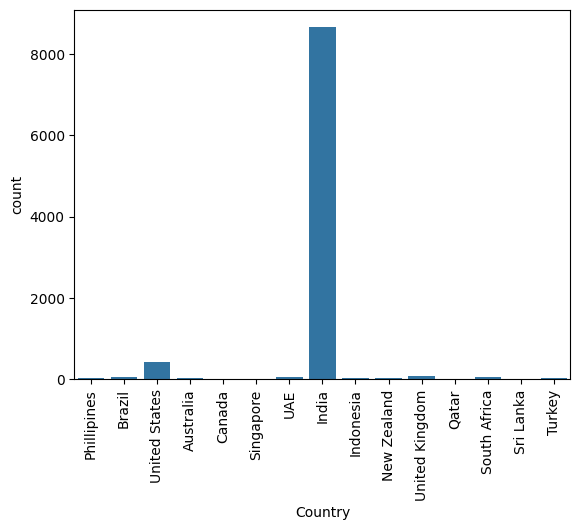

In [15]:
sns.countplot(data=df2,x="Country")
plt.tick_params(axis="x",labelrotation=90)
plt.show()

Text(0.5, 1.0, 'Top 10 Cuisines')

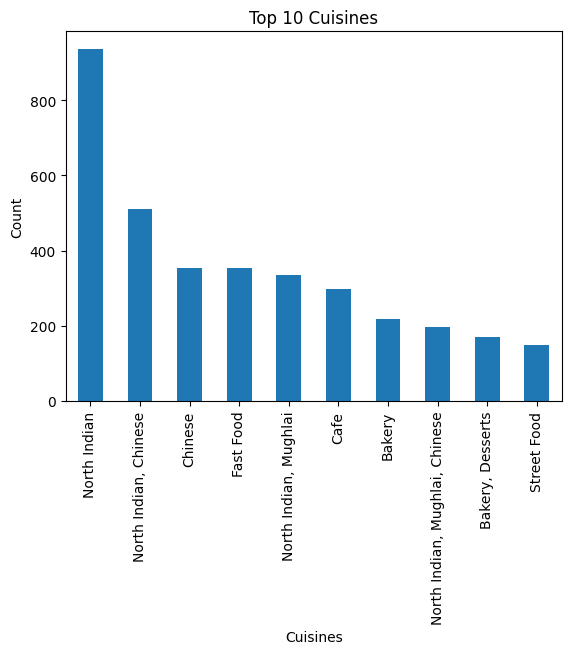

In [16]:
df2["Cuisines"].value_counts().head(10).plot(kind="bar")
plt.xlabel("Cuisines")
plt.ylabel("Count")
plt.title("Top 10 Cuisines")

Text(0.5, 1.0, 'Top Rated Cuisines')

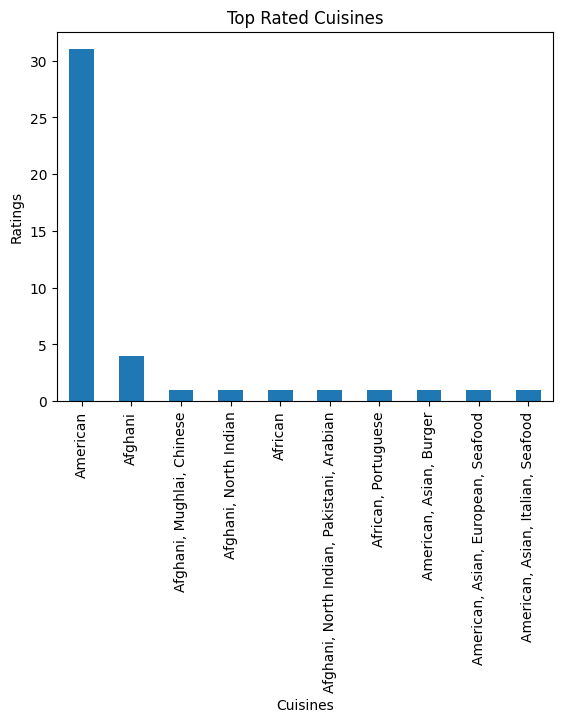

In [41]:
df2.groupby("Cuisines")["Rating text"].count().head(10).sort_values(ascending=False).plot(kind="bar")
plt.xlabel("Cuisines")
plt.ylabel("Ratings")
plt.title("Top Rated Cuisines")

Text(0.5, 1.0, 'Top Rated Cusines')

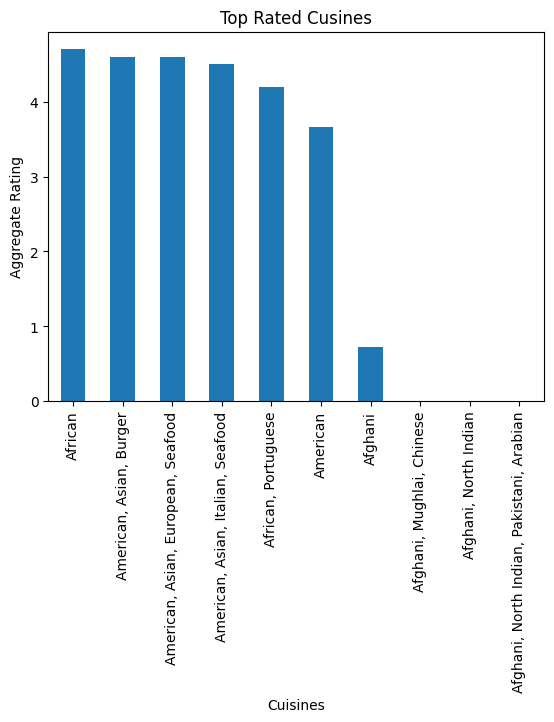

In [40]:
df2.groupby("Cuisines")["Aggregate rating"].mean().head(10).sort_values(ascending=False).plot(kind="bar")
plt.xlabel("Cuisines")
plt.ylabel("Aggregate Rating")
plt.title("Top Rated Cusines")

In [19]:
print(df2.groupby("Aggregate rating")["Rating text"].count().head(10).sort_values(ascending=False))

Aggregate rating
0.0    2148
2.6     191
2.5     110
2.4      87
2.3      47
2.2      27
2.1      15
2.0       7
1.9       2
1.8       1
Name: Rating text, dtype: int64


In [20]:
pd.crosstab(df["Price range"], df["Has Online delivery"])

Has Online delivery,No,Yes
Price range,,
1,3737,701
2,1827,1286
3,994,411
4,533,53


Text(0.5, 1.0, 'Cities Having Highest Restaurant Rating')

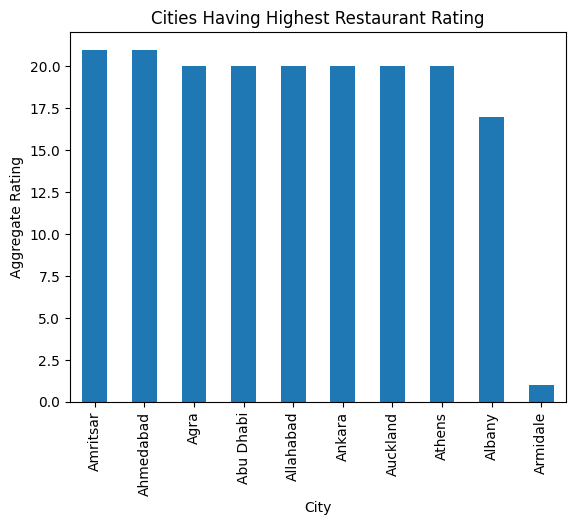

In [39]:
#Cities having highest restaurant rating
df2.groupby("City")["Aggregate rating"].count().head(10).sort_values(ascending=False).plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Aggregate Rating")
plt.title("Cities Having Highest Restaurant Rating")

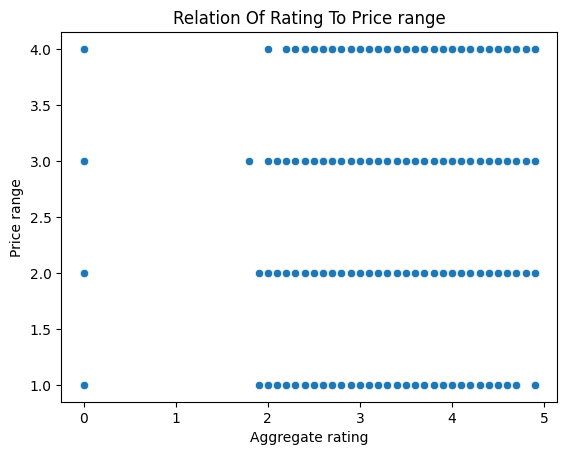

In [33]:
sns.scatterplot(data=df2,x="Aggregate rating",y="Price range")
plt.title("Relation Of Rating To Price range")
plt.show()


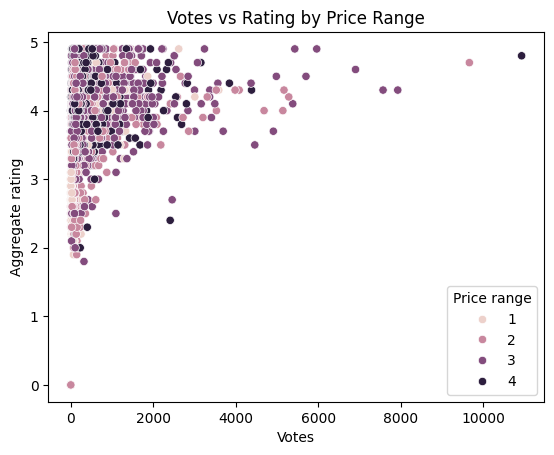

In [30]:
sns.scatterplot(
    data=df2,
    x="Votes",
    y="Aggregate rating",
    hue="Price range"
)

plt.title("Votes vs Rating by Price Range")
plt.show()

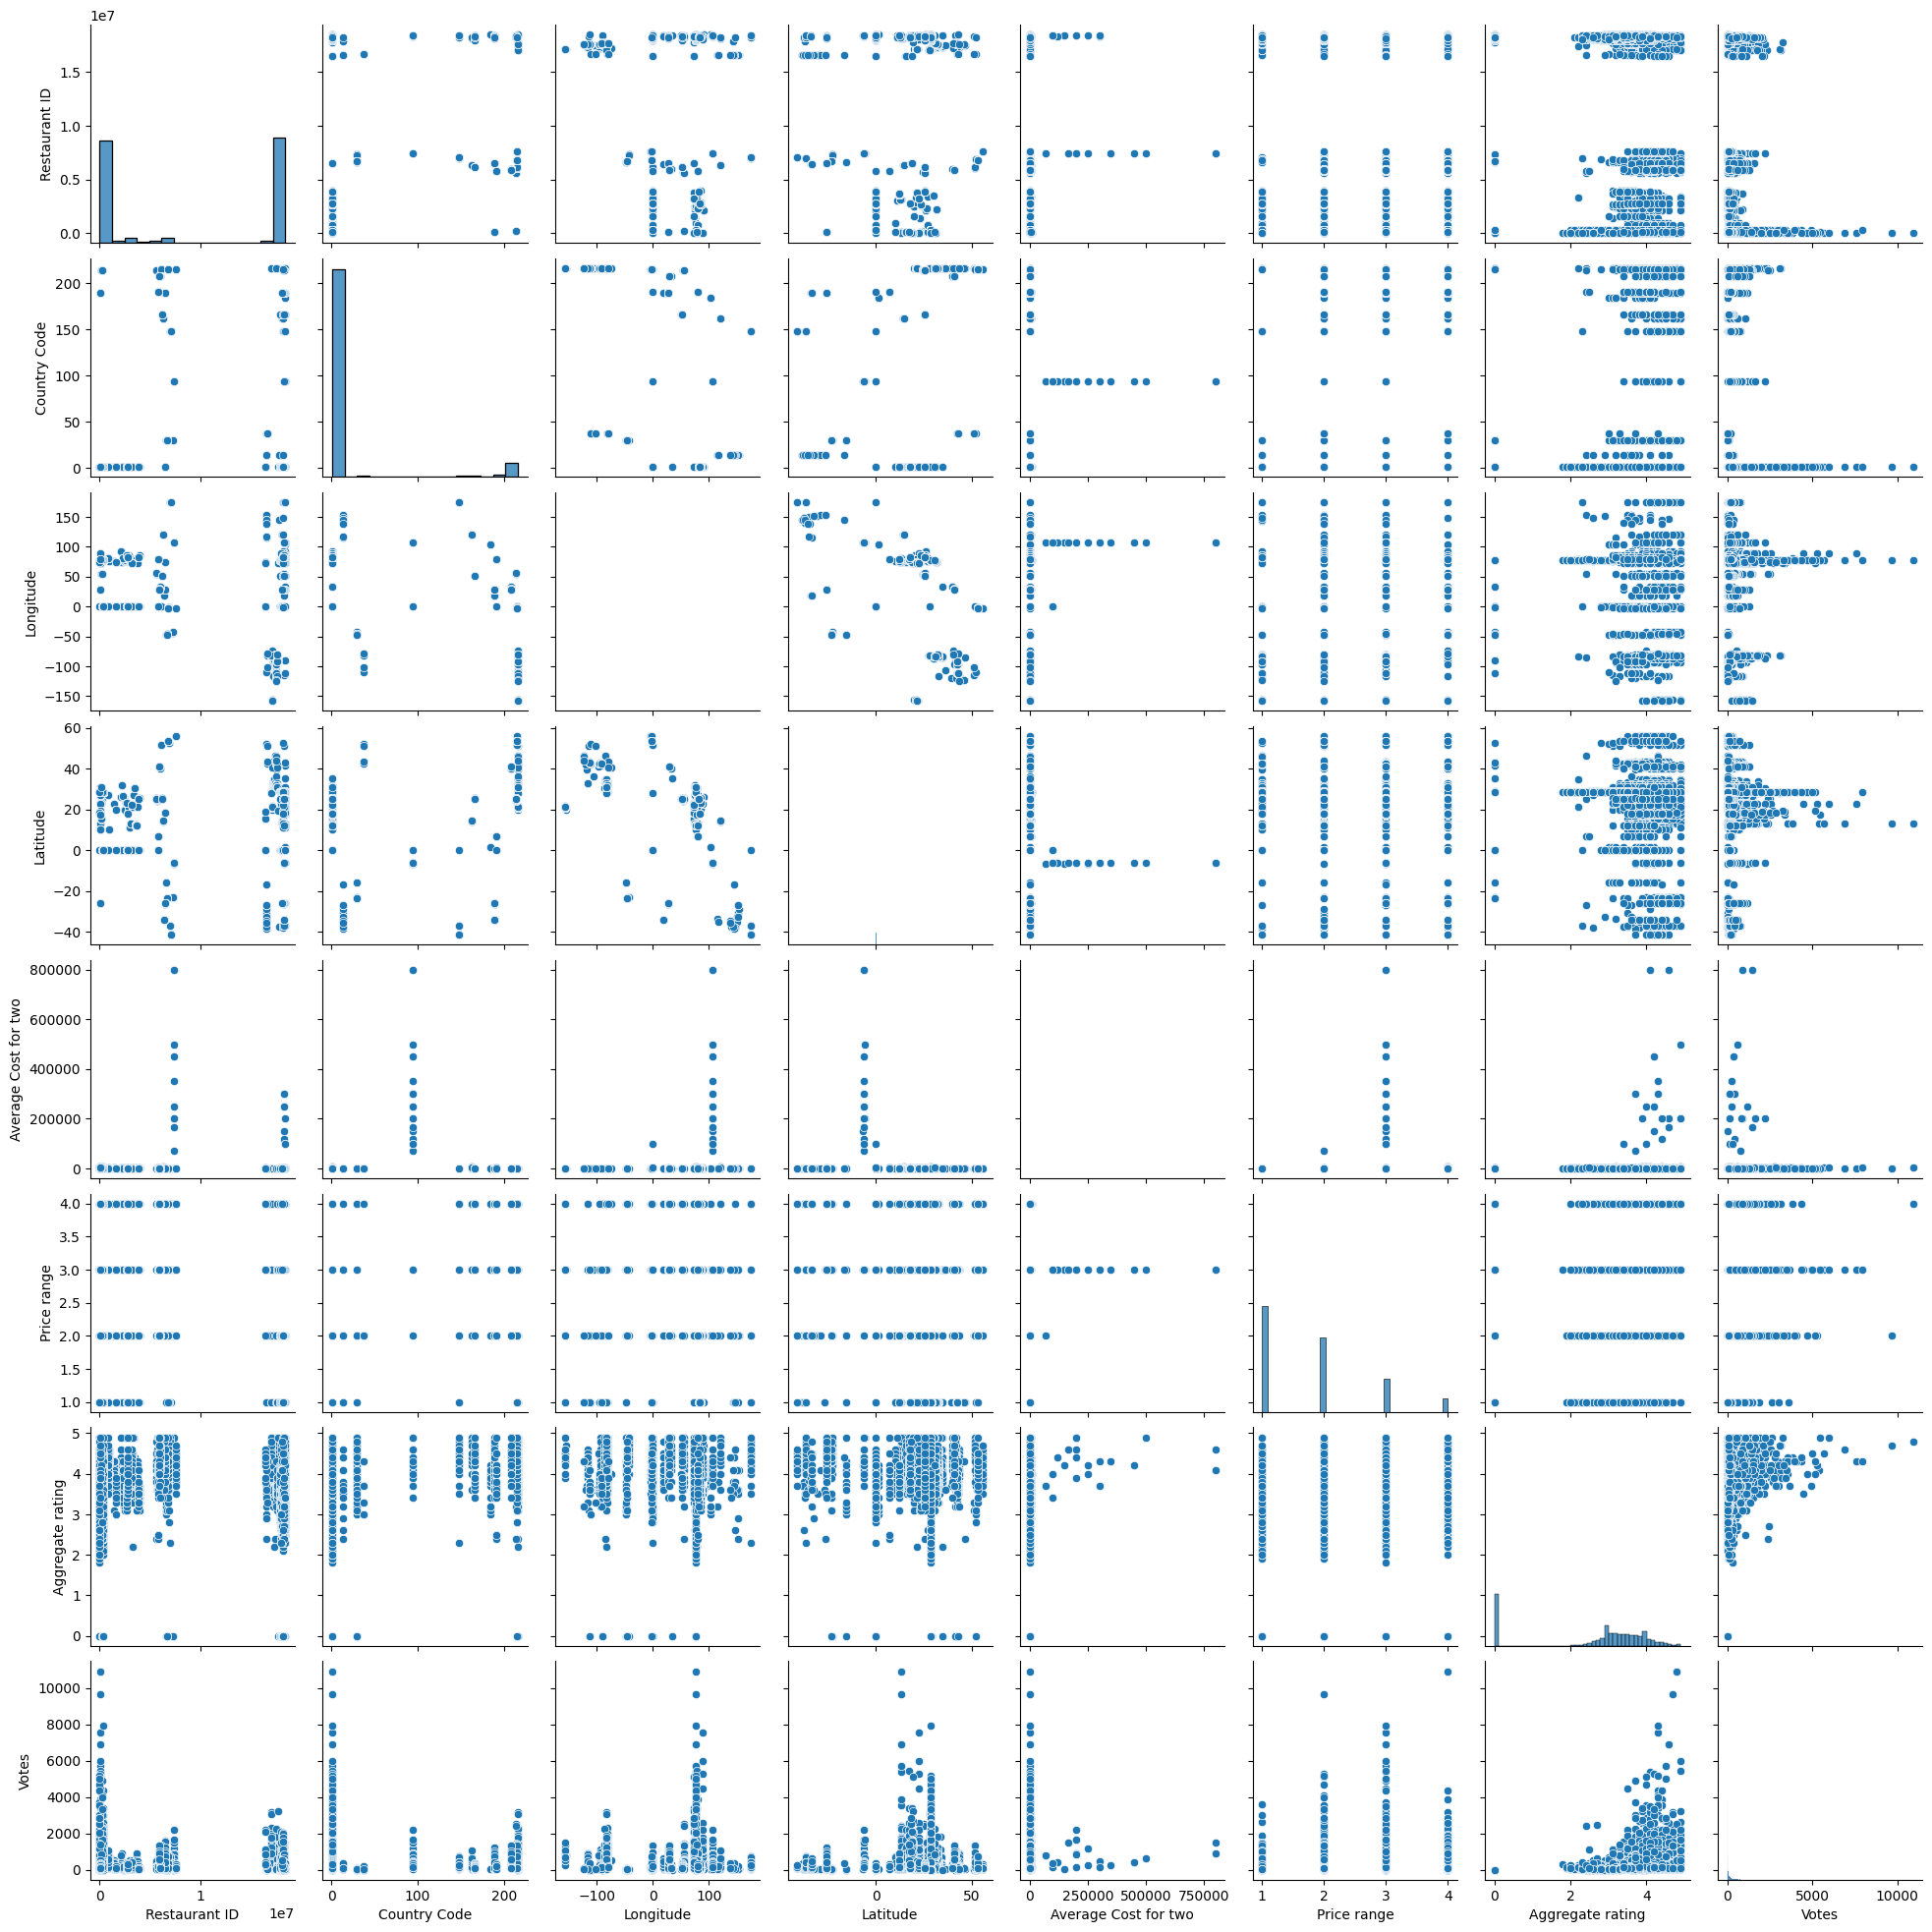

In [34]:
sns.pairplot(data=df2)
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x78b4dce9bfe0>,
 'caps': [<matplotlib.lines.Line2D at 0x78b4dcf052e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78b4dcf7d1c0>],
 'medians': [<matplotlib.lines.Line2D at 0x78b4dcf070b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x78b4dcf07c20>],
 'means': []}

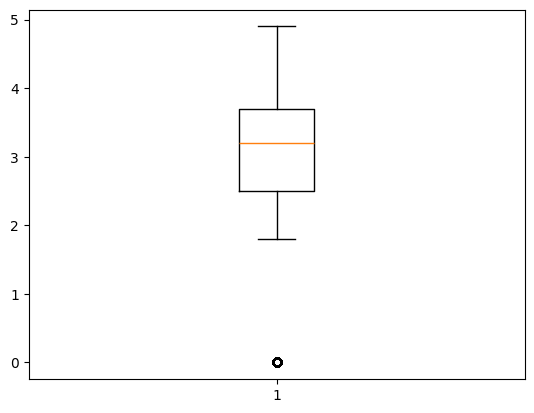

In [35]:
plt.boxplot(df2["Aggregate rating"])

<Axes: ylabel='Votes'>

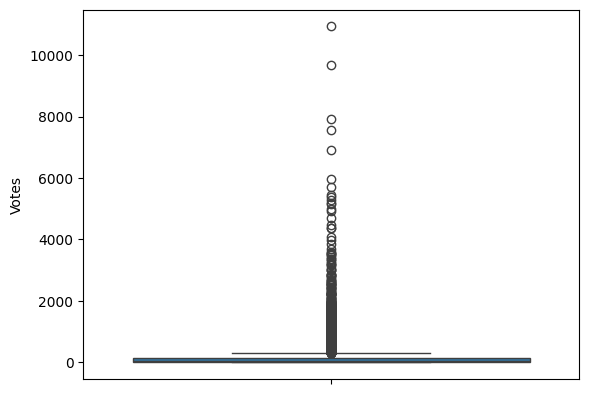

In [36]:
sns.boxplot(df2["Votes"])

<Axes: ylabel='Price range'>

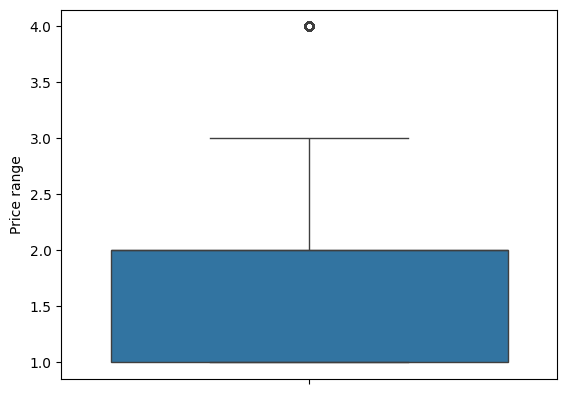

In [37]:
sns.boxplot(df2["Price range"])